# Lab 2 – Digital Image Fundamentals

## Image Sampling and Quantization

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    return cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)

def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    return quantized_image.astype(np.uint8)

def plot_images(original, sampled, quantized):
    """Plots the original, sampled, and quantized images side by side."""
    plt.figure(figsize=(12, 4))
    for i, (im, t) in enumerate([(original, 'Original Image'), (sampled, 'Sampled Image'), (quantized, 'Quantized Image')], 1):
        plt.subplot(1, 3, i)
        plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
    plt.show()

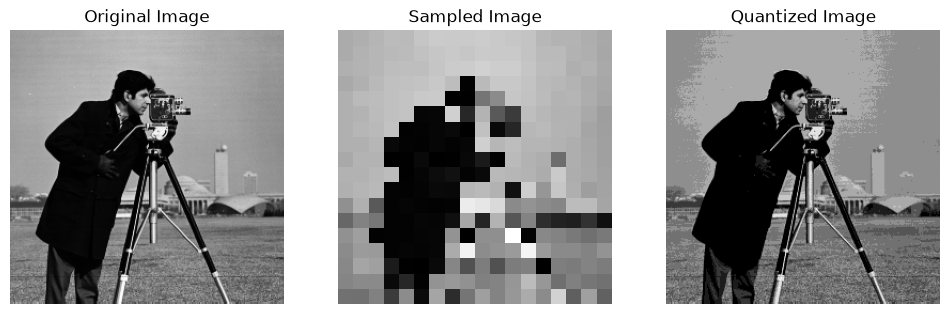

In [2]:
image_path = '../images/cameraman.tiff'
sampling_factor = 14
quantization_levels = 9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

# Assessment
## Task 1: Change the sampling and quantization parameters

sampling factor = 2, quantization levels = 128


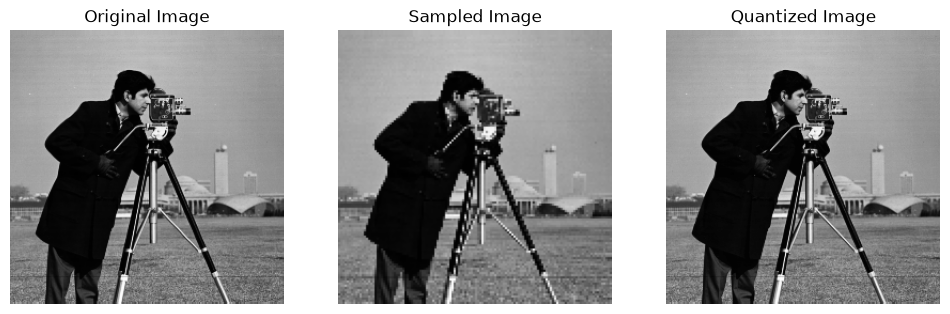

sampling factor = 4, quantization levels = 32


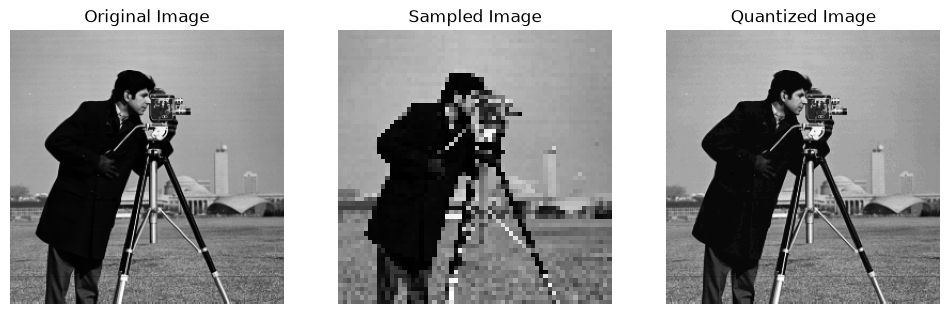

sampling factor = 8, quantization levels = 8


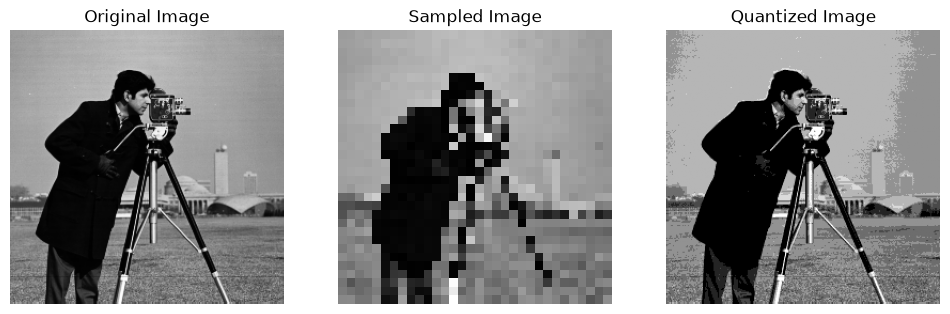

sampling factor = 16, quantization levels = 4


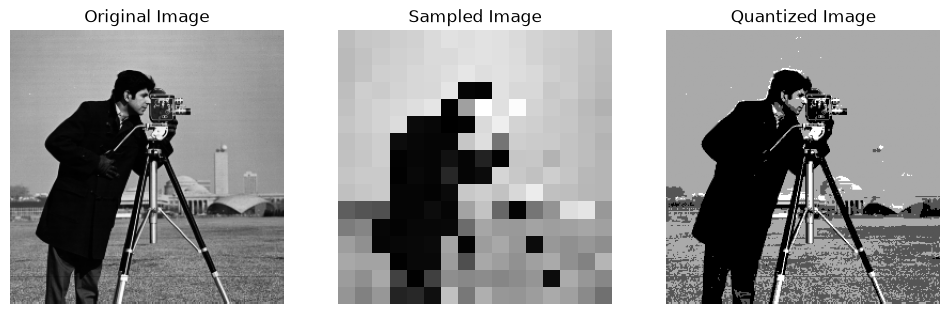

sampling factor = 32, quantization levels = 2


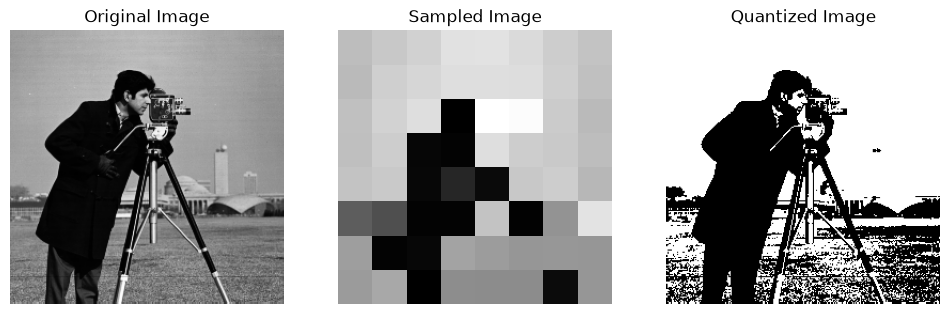

In [3]:
for factor, levels in [(2, 128), (4, 32), (8, 8), (16, 4), (32, 2)]:
    print(f'sampling factor = {factor}, quantization levels = {levels}')
    plot_images(original_image, sample_image(original_image, factor), quantize_image(original_image, levels))

## Task 2: Operations on two images

In [4]:
from PIL import Image

resize = (400, 400)
img1 = Image.open('../images/cameraman.tiff').resize(resize, Image.Resampling.LANCZOS)
from skimage import data
img2 = Image.fromarray(data.moon()).resize(resize, Image.Resampling.LANCZOS)   # second image: moon
im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

def show(images, titles):
    plt.figure(figsize=(4 * len(images), 4))
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(t); plt.axis('off')
    plt.show()

### Addition of two images
Plain `+` on uint8 arrays wraps around past 255, so `cv2.add` (saturating) is used.

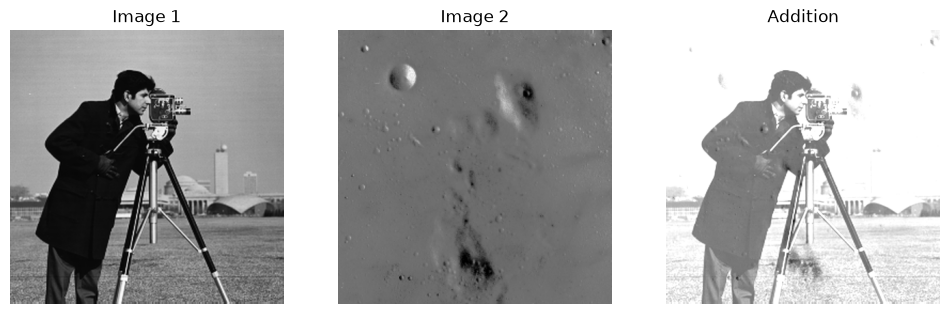

In [5]:
addition = cv2.add(im1arr, im2arr)
show([im1arr, im2arr, addition], ['Image 1', 'Image 2', 'Addition'])

### Subtract two images

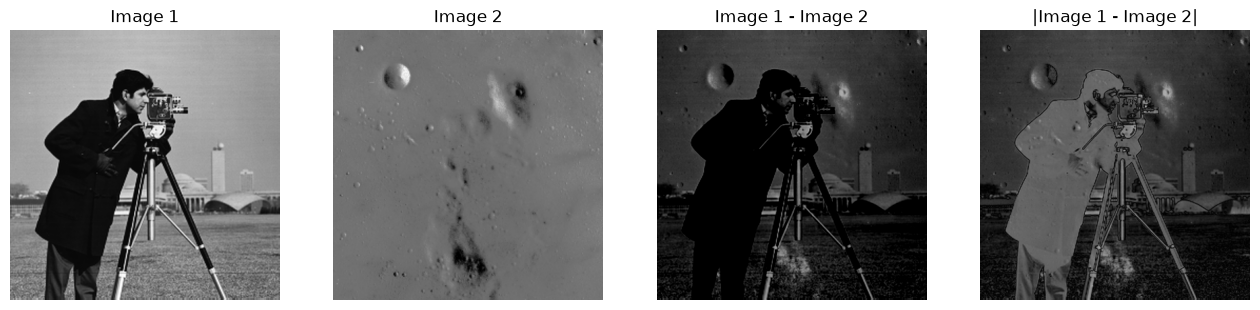

In [6]:
subtraction = cv2.subtract(im1arr, im2arr)   # saturates at 0
abs_diff = cv2.absdiff(im1arr, im2arr)
show([im1arr, im2arr, subtraction, abs_diff], ['Image 1', 'Image 2', 'Image 1 - Image 2', '|Image 1 - Image 2|'])

### Add a constant value of 175

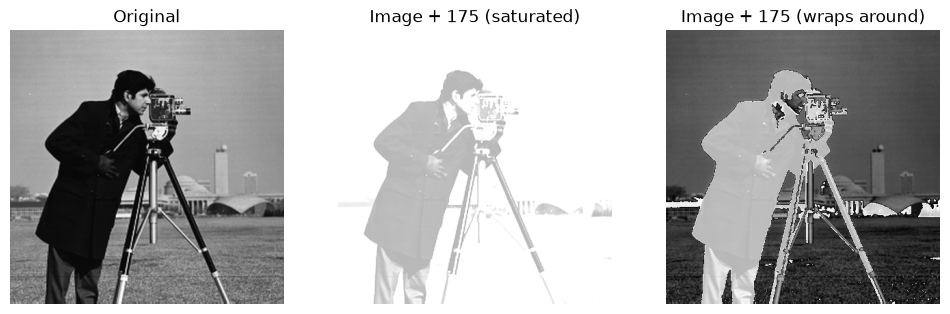

In [7]:
const_add = cv2.add(im1arr, 175)   # clipped to 255
wrapped = ((im1arr.astype(np.int32) + 175) % 256).astype(np.uint8)   # what plain uint8 addition would produce
show([im1arr, const_add, wrapped], ['Original', 'Image + 175 (saturated)', 'Image + 175 (wraps around)'])

### Set and logical operations on grayscale images
For grayscale sets: union = max, intersection = min, complement = 255 - a. Set difference A - B = A ∩ complement(B). Symmetric difference = (A - B) ∪ (B - A).

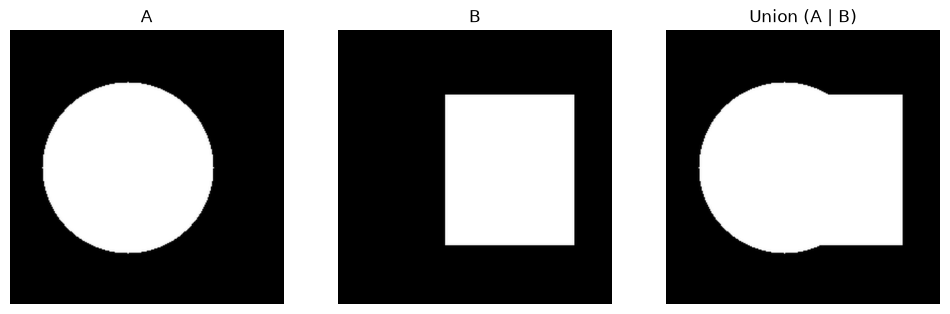

In [8]:
A = np.asarray(Image.open('../images/A.png').convert('L').resize(resize, Image.Resampling.LANCZOS))
B = np.asarray(Image.open('../images/B.png').convert('L').resize(resize, Image.Resampling.LANCZOS))

def union(a, b): return np.maximum(a, b)
def intersection(a, b): return np.minimum(a, b)
def difference(a, b): return np.minimum(a, 255 - b)
def sym_difference(a, b): return np.maximum(difference(a, b), difference(b, a))

show([A, B, union(A, B)], ['A', 'B', 'Union (A | B)'])

A and B (binary shapes)


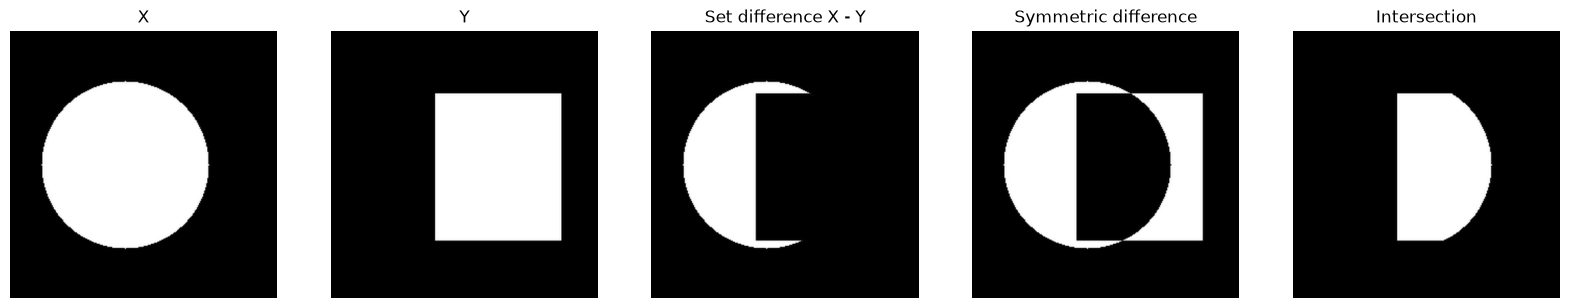

Cameraman and Moon (grayscale)


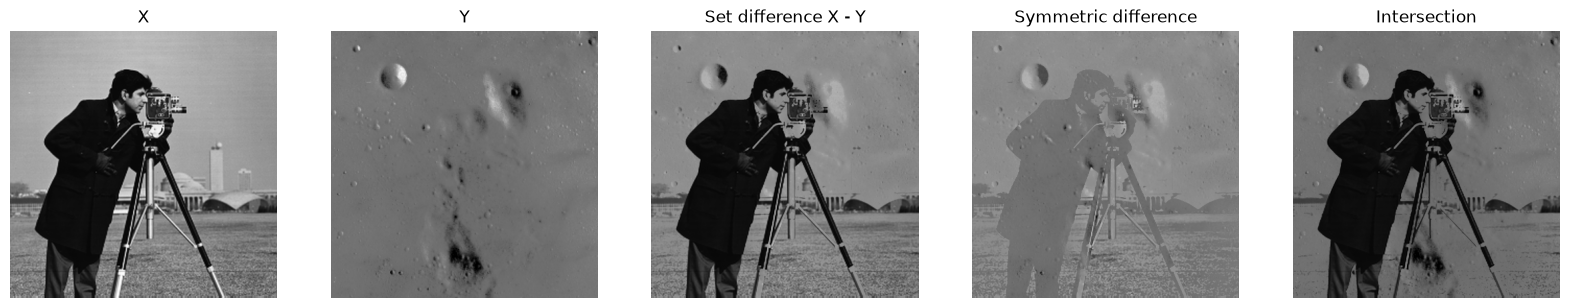

In [9]:
for name, (x, y) in {'A and B (binary shapes)': (A, B), 'Cameraman and Moon (grayscale)': (im1arr, im2arr)}.items():
    print(name)
    show([x, y, difference(x, y), sym_difference(x, y), intersection(x, y)],
         ['X', 'Y', 'Set difference X - Y', 'Symmetric difference', 'Intersection'])